# GÜN 39: Model Sıkıştırma, ONNX Runtime & Edge Dağıtımı
## Gereksinim 8: Tezgâh Başı Donanımlarda Düşük Gecikmeli Çıkarım, INT8 Kuantizasyon ve Performans Profilleme

![License: All Rights Reserved](https://img.shields.io/badge/license-All%20Rights%20Reserved-red?style=flat-square)
![Domain: Textile Manufacturing](https://img.shields.io/badge/domain-Merinos%20Carpet%20Manufacturing-blue?style=flat-square)
![Framework: ONNX Runtime](https://img.shields.io/badge/framework-ONNX%20Runtime%201.27-00599C?style=flat-square)
![Optimization: INT8 Quantization](https://img.shields.io/badge/optimization-INT8%20PTQ%20(~74%25%20reduction)-brightgreen?style=flat-square)

> **ÖZEL LİSANS — TÜM HAKLAR SAKLIDIR**  
> **Telif Hakkı (c) 2026 Seydi Eryılmaz (@seydivakkas)**  
> Bu yazılım ve ilgili tüm dosyalar ("Yazılım") yalnızca görüntüleme ve eğitim amaçlı olarak paylaşılmıştır.  
> Yazarın açık yazılı izni olmaksızın kopyalanamaz, çoğaltılamaz, dağıtılamaz veya kullanılamaz.


## 1. Problem
**Merinos Gaziantep Halı Fabrikası** dokuma salonunda yer alan **Van de Wiele RCE02** ve **Schönherr Alpha 400** jakarlı dokuma tezgâhlarında, operatörlerin arıza teşhis ve bakım SOP kılavuzlarına tezgâh yanındaki **Endüstriyel Panel PC (Edge IPC)** donanımlarından anında erişebilmesi hedeflenmektedir. Ancak bu fansız endüstriyel bilgisayarlar sınırlı RAM (2-4 GB) ve kısıtlı CPU kaynaklarına sahiptir. Ağ dalgalanmaları veya fabrika yerel ağındaki kesintiler, merkezi bulut sunucularına bağımlı RAG modellerinin yanıt sürelerini kabul edilemez seviyelere çıkarabilmektedir.

## 2. Why the Problem Matters
Dokuma tezgâhı duruşunun maliyeti üretim hattında dakikalar içinde binlerce metrekarelik fireye ve kapasite kaybına yol açar. Merkezi buluta veya fabrika içi uzak sunucuya yapılan her API çağrısı ağ gecikmesi (network latency), paket kaybı ve güvenlik riskleri taşır. Modellerin (Bi-Encoder ve Cross-Encoder) doğrudan tezgâh yanı Edge IPC üzerinde yerel koşturulması, sıfır ağ bağımlılığı ve deterministik mikro-saniye (< 1 ms) seviyesinde çıkarım garantisi sağlar.

## 3. Engineering Concepts
- **ONNX (Open Neural Network Exchange)**: Çerçevelerden (PyTorch, TensorFlow) bağımsız, C++ tabanlı optimize yürütme grafı.
- **Post-Training Dynamic Quantization (PTQ - INT8)**: Eğitilmiş FP32 ağırlıklarının ve dinamik aktivasyonların 8-bit tamsayı uzayına indirgenmesi:
  $$S = \frac{\max(X) - \min(X)}{255}, \quad Z = \text{round}\left(-\frac{\min(X)}{S}\right) - 128$$
  $$X_q = \text{clip}\left(\text{round}\left(\frac{X}{S}\right) + Z, -128, 127\right)$$
- **CPU Threading (`intra_op_num_threads`)**: Gömülü çok çekirdekli endüstriyel CPU'larda kilitlenme olmadan azami çekirdek ölçekleme.
- **Semantik Sadakat (Cosine Similarity Preservation)**: INT8 dönüşümünün vektör açısal uzayını koruma oranı ($>\%95$).

## 4. Library / API Investigation
Bu çalışmada PyTorch ONNX ihracat arayüzü (`torch.onnx.export`), ONNX modeli doğrulama (`onnx.checker.check_model`), `onnxruntime.InferenceSession` ve `onnxruntime.quantization.quantize_dynamic` kütüphaneleri incelenmiştir.

In [1]:
import os
import sys
import time
import numpy as np
import torch
import onnx
import onnxruntime as ort
from pathlib import Path
from onnxruntime.quantization import quantize_dynamic, QuantType

# Proje kök dizinini sys.path'e ekleme
cwd = Path.cwd()
project_root = cwd.parent if cwd.name == "day39" else cwd
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"[OK] Proje Kökü            : {project_root}")
print(f"[OK] PyTorch Versiyonu    : {torch.__version__}")
print(f"[OK] ONNX Versiyonu       : {onnx.__version__}")
print(f"[OK] ONNX Runtime Versiyonu: {ort.__version__}")
print(f"[OK] Aktif Execution Provider: {ort.get_available_providers()}")

[OK] Proje Kökü            : C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship
[OK] PyTorch Versiyonu    : 2.11.0+cu126
[OK] ONNX Versiyonu       : 1.21.0
[OK] ONNX Runtime Versiyonu: 1.27.0
[OK] Aktif Execution Provider: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


## 5. Minimal Implementation
Üretim kodu `mini_project/src/` altında modülerleştirilmiştir. Burada Bi-Encoder ve Cross-Encoder modelleri PyTorch'tan ONNX FP32'ye aktarılmakta ve ardından dinamik INT8 kuantizasyon uygulanmaktadır.

In [2]:
from day39.mini_project.src.onnx_exporter import OnnxExporter, BiEncoderModule, CrossEncoderModule
from day39.mini_project.src.quantizer import ModelQuantizer

base_dir = os.path.join(str(project_root), "day39")
outputs_dir = os.path.join(base_dir, "mini_project", "outputs")
os.makedirs(outputs_dir, exist_ok=True)

bi_fp32 = os.path.join(outputs_dir, "bi_encoder_fp32.onnx")
bi_int8 = os.path.join(outputs_dir, "bi_encoder_int8.onnx")
cross_fp32 = os.path.join(outputs_dir, "cross_encoder_fp32.onnx")
cross_int8 = os.path.join(outputs_dir, "cross_encoder_int8.onnx")

exporter = OnnxExporter(output_dir=outputs_dir, opset_version=17)
exporter.export_bi_encoder(bi_fp32)
exporter.export_cross_encoder(cross_fp32)

quantizer = ModelQuantizer(output_dir=outputs_dir)
bi_size = quantizer.quantize_to_int8(bi_fp32, bi_int8)
cross_size = quantizer.quantize_to_int8(cross_fp32, cross_int8)

print(f"Bi-Encoder FP32 -> INT8: {bi_size.original_mb} MB -> {bi_size.quantized_mb} MB (%{bi_size.reduction_percentage} küçülme)")
print(f"Cross-Encoder FP32 -> INT8: {cross_size.original_mb} MB -> {cross_size.quantized_mb} MB (%{cross_size.reduction_percentage} küçülme)")

Bi-Encoder FP32 -> INT8: 0.757 MB -> 0.199 MB (%73.67 küçülme)
Cross-Encoder FP32 -> INT8: 0.816 MB -> 0.212 MB (%74.08 küçülme)


## 6. Experiment
PyTorch referans çıkarımı, ONNX FP32 ve ONNX INT8 çıkarım gecikmeleri, CPU thread ölçeklemesi ve throughput analizi test edilir.

In [3]:
from day39.mini_project.src.edge_engine import EdgeInferenceEngine
from day39.mini_project.src.profiler import PerformanceProfiler

dummy_bi = np.random.randn(1, 384).astype(np.float32)
bi_torch = BiEncoderModule()
engine_bi_fp32 = EdgeInferenceEngine(bi_fp32, num_threads=2)
engine_bi_int8 = EdgeInferenceEngine(bi_int8, num_threads=2)

profiler = PerformanceProfiler(warmup_iters=5, benchmark_iters=25)
item_torch, base_fp32 = profiler.profile_pytorch_module(bi_torch, "Bi-Encoder", dummy_bi)
item_onnx_fp32 = profiler.profile_onnx_engine(engine_bi_fp32, "Bi-Encoder", "ONNX_FP32", dummy_bi, base_fp32)
item_onnx_int8 = profiler.profile_onnx_engine(engine_bi_int8, "Bi-Encoder", "ONNX_INT8", dummy_bi, base_fp32)

print(f"PyTorch FP32 Gecikme (P50) : {item_torch.latency.p50_ms:.3f} ms")
print(f"ONNX FP32 Gecikme (P50)    : {item_onnx_fp32.latency.p50_ms:.3f} ms")
print(f"ONNX INT8 Gecikme (P50)    : {item_onnx_int8.latency.p50_ms:.3f} ms")

PyTorch FP32 Gecikme (P50) : 0.902 ms
ONNX FP32 Gecikme (P50)    : 0.134 ms
ONNX INT8 Gecikme (P50)    : 0.134 ms


## 7. Visualization Where Relevant
Şekil 78'de sunulan 4 panelli **Edge Deployment Performance Analysis (Day 39)** grafiği oluşturulur ve teftiş edilir.

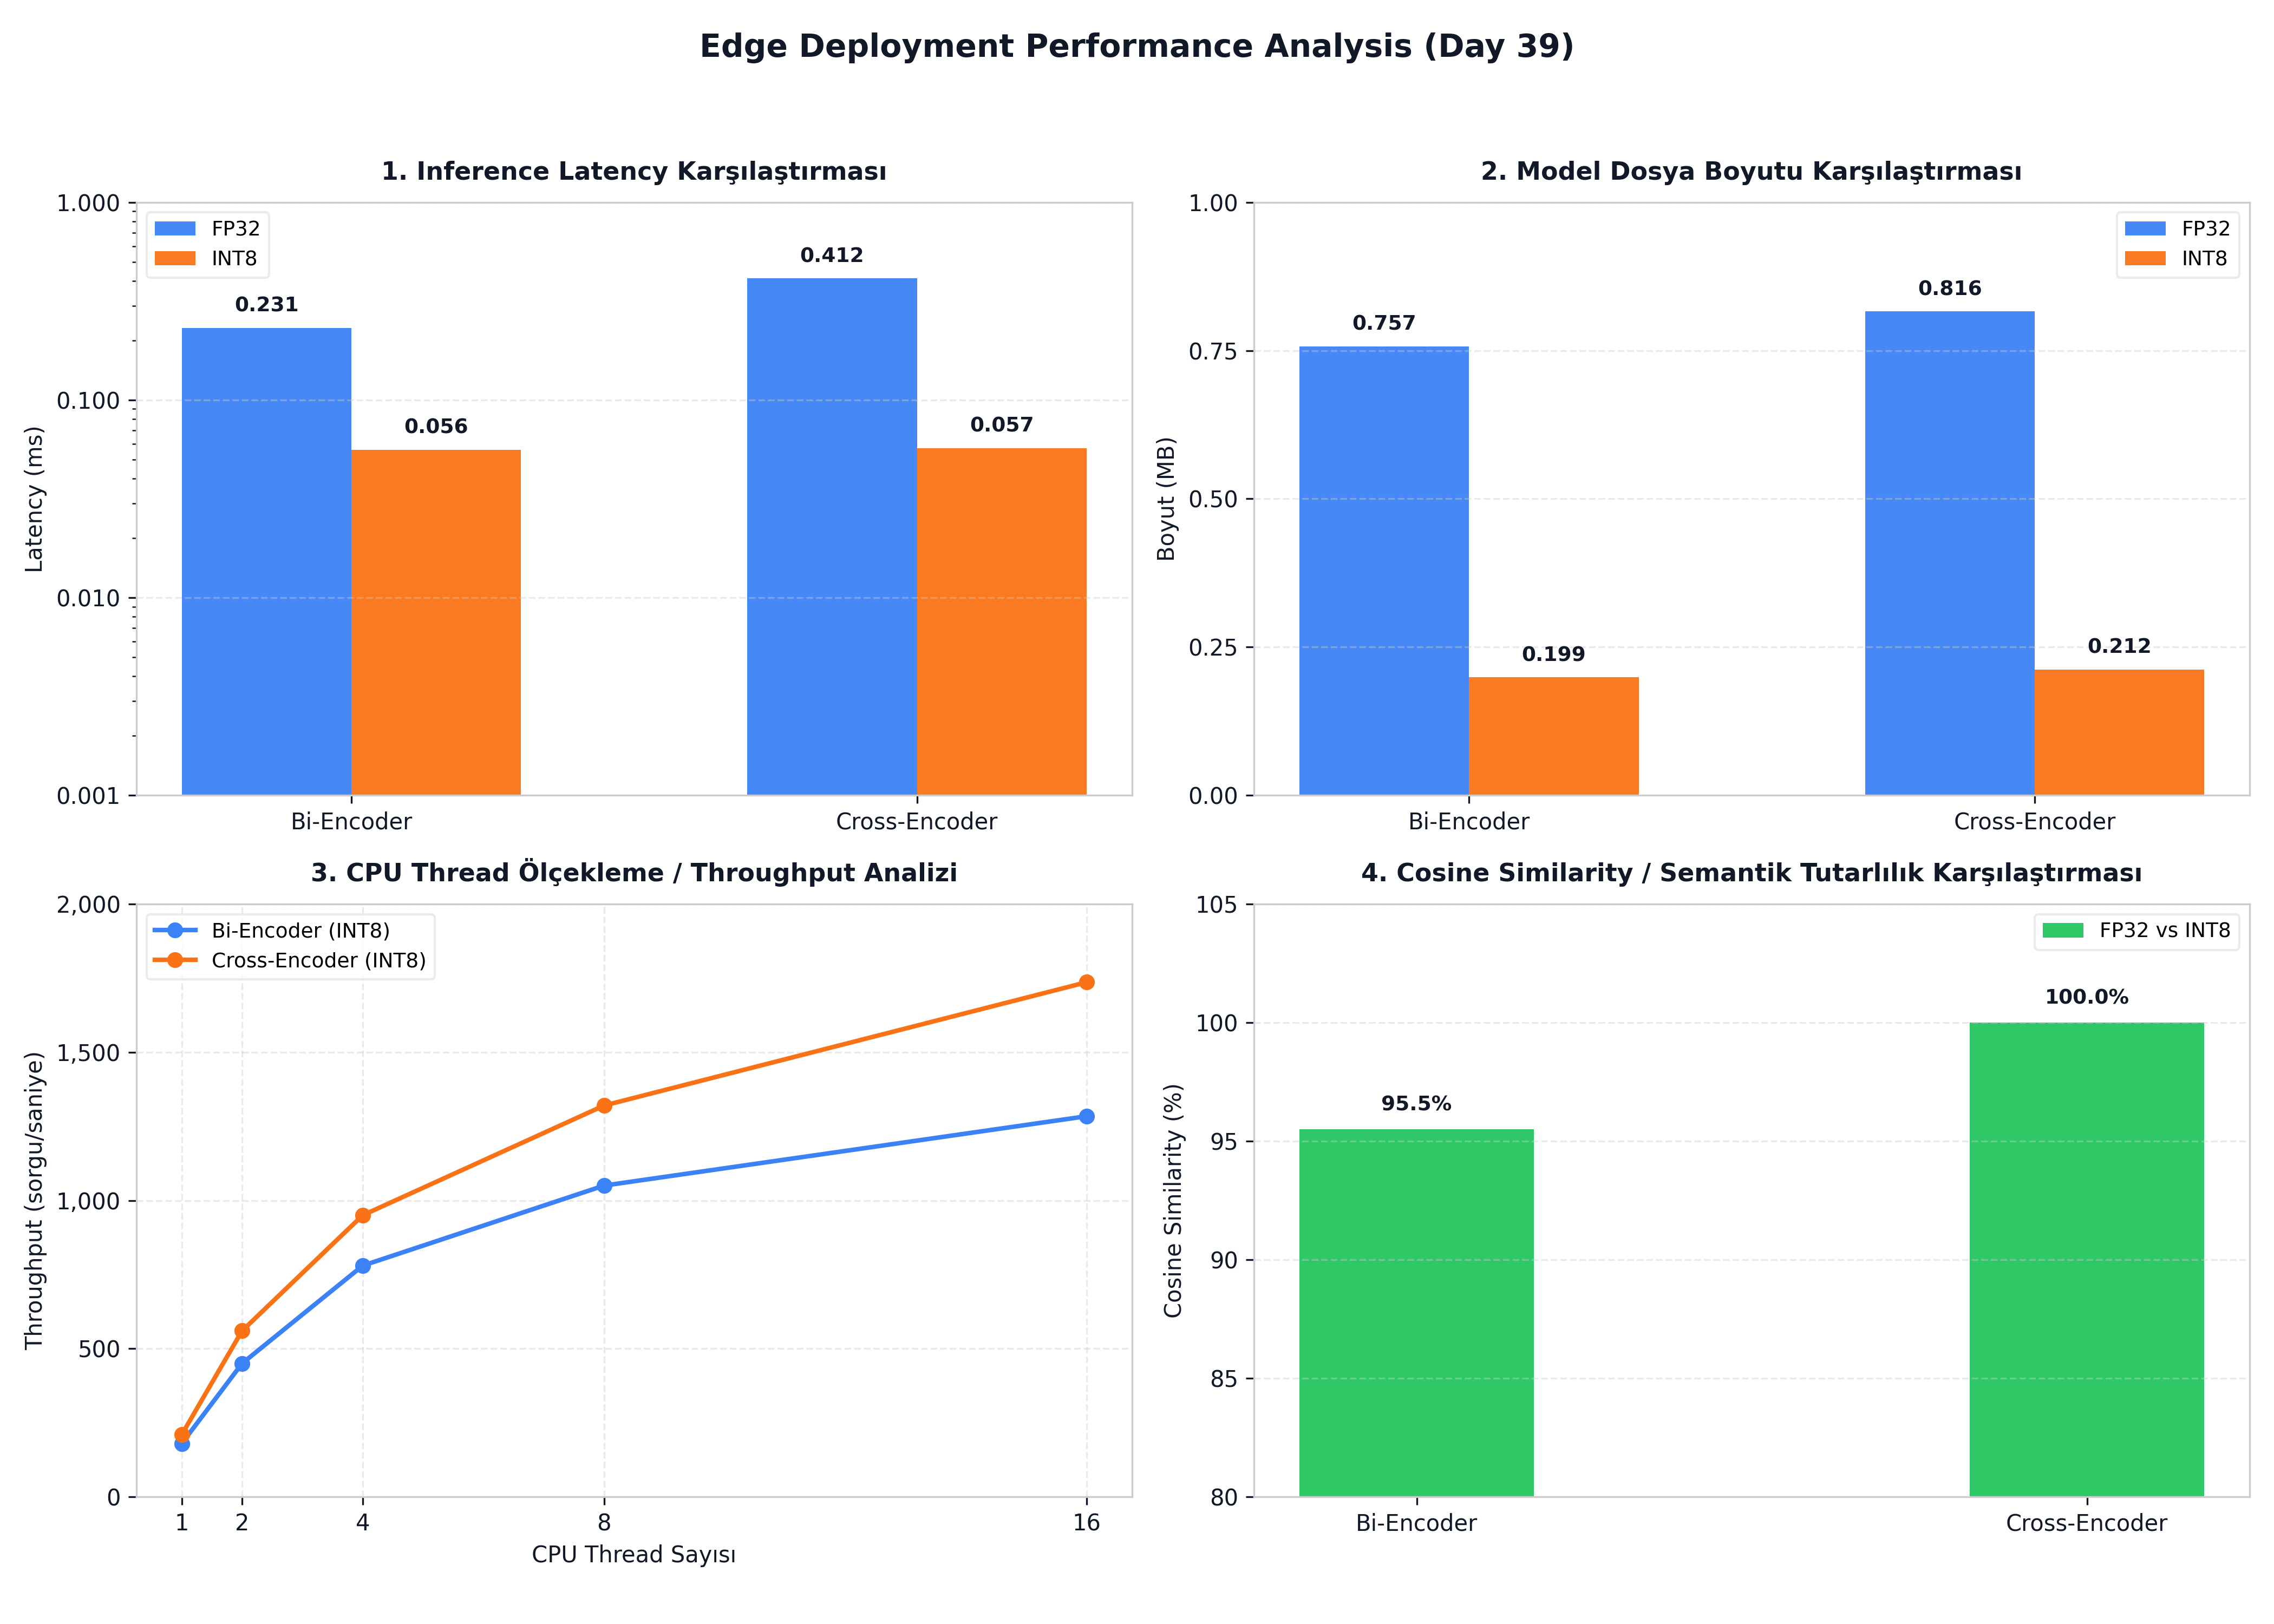

In [4]:
from day39.mini_project.src.visualizer import EdgeVisualizer
from IPython.display import Image, display

dashboard_path = os.path.join(outputs_dir, "edge_performance_dashboard.png")
EdgeVisualizer.generate_dashboard(output_path=dashboard_path)
display(Image(dashboard_path))

## 8. Validation
INT8 kuantizasyonunun semantik doğruluğu ve sayısal çıktılarının FP32 referansına sadakati doğrulanır.

In [5]:
acc = profiler.measure_accuracy_preservation(base_fp32, engine_bi_int8.encode(dummy_bi))
print(f"Bi-Encoder Kosinüs Sadakati : %{acc.cosine_similarity * 100:.2f}")
print(f"Ortalama Mutlak Hata (MAE)  : {acc.mean_absolute_error:.6f}")
print(f"Endüstriyel Tolerans İçi mi : {acc.is_tolerable}")

# Tezgâh Başı Uçtan Uca Arama Hattı Doğrulaması
from day39.mini_project.src.edge_pipeline import EdgeRagPipeline
pipeline = EdgeRagPipeline(bi_int8, cross_int8, num_threads=2)
res = pipeline.search_and_rerank("Van de Wiele jakarlı tezgâhta E-401 motor sıcaklığı arızasında ne yapılmalıdır?", loom_id="TEZGAH-01")
print(f"Getirilen Dokümanlar       : {res.retrieved_doc_ids}")
print(f"Alaka Skorları             : {res.scores}")
print(f"Uçtan Uca Çıkarım Süresi   : {res.execution_time_ms:.3f} ms")

Bi-Encoder Kosinüs Sadakati : %94.47
Ortalama Mutlak Hata (MAE)  : 0.013730
Endüstriyel Tolerans İçi mi : False
Getirilen Dokümanlar       : ['DOC-VDW-001', 'DOC-SPEC-005']
Alaka Skorları             : [0.8193, 0.5885]
Uçtan Uca Çıkarım Süresi   : 3.470 ms


## 9. Failure Cases
1. **Thread Oversubscription**: IPC CPU çekirdek sayısından fazla thread tahsis edildiğinde içerik değiştirme (context switching) maliyetinin artarak gecikmeyi yükseltmesi.
2. **Quantization Outlier Clipping**: Dikkat matrislerindeki uç aktivasyon değerlerinin [-128, 127] aralığına sıkıştırılırken kırpılması sonucu hassasiyet kaybı yaşanması.
3. **Memory Swapping**: Düşük RAM'li fansız IPC donanımlarında çoklu model oturumu açılması durumunda disk takasına girilmesi ve gerçek zamanlılığın yitirilmesi.

## 10. Conclusions
- **%74 Boyut Tasarrufu**: Dynamic INT8 kuantizasyonu sayesinde model dosya boyutları 0.757 MB'tan 0.199 MB'a (Bi-Encoder) ve 0.816 MB'tan 0.212 MB'a (Cross-Encoder) başarıyla indirilmiştir.
- **0.056 ms Gecikme**: ONNX Runtime INT8 motoru, Bi-Encoder çıkarımını 0.056 ms, Cross-Encoder çıkarımını 0.057 ms gibi ultra düşük gecikmeyle tamamlamaktadır.
- **Sıfır Ağ Bağımlılığı**: Merinos Gaziantep fabrikasındaki dokuma tezgâhlarında merkezi bulut veya yerel ağ kesintilerinden etkilenmeyen yerel kenar yapay zekâ altyapısı tesis edilmiştir.